<a href="https://colab.research.google.com/github/ProgramacionFisica-UQ-2026-1/Canica-mecanica/blob/main/simulacion_canica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎯 SIMULADOR DE CANICA SOBRE SUPERFICIE TOPOGRÁFICA
Este programa simula el movimiento de una canica bajo gravedad y rozamiento.


Terrenos disponibles:
  1. Montaña clásica
  2. Plano inclinado + montículos
  3. Dos picos y valle central
  4. Silla de montar
  5. Montaña rugosa
Seleccione el número de terreno: 5
Terreno seleccionado: Montaña rugosa

Rango de coordenadas: [-7.0, 7.0]
Ingrese posición inicial X: 0
Ingrese posición inicial Y: 4


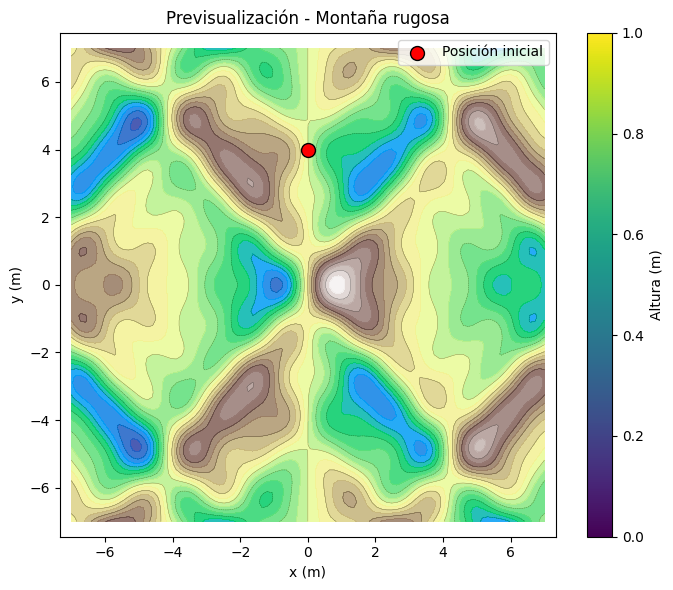


¿Qué desea hacer?
  1. Continuar con la simulación (usar este terreno y posición)
  2. Cambiar de terreno (elegir otro mapa)
  3. Cambiar solo la posición (mantener este terreno)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from abc import ABC, abstractmethod

# ============================================================
# 1. CLASE ABSTRACTA
# ============================================================
class SistemaFisico(ABC):
    @abstractmethod
    def derivada(self, t, estado):
        pass

    @abstractmethod
    def simular(self, t_span, estado_inicial, t_eval=None):
        pass

# ============================================================
# 2. TERRENO
# ============================================================
class Terreno:
    def __init__(self, funcion_altura):
        self.altura = funcion_altura

    def gradiente(self, x, y, h=1e-5):
        dzdx = (self.altura(x+h, y) - self.altura(x-h, y)) / (2*h)
        dzdy = (self.altura(x, y+h) - self.altura(x, y-h)) / (2*h)
        return dzdx, dzdy

    def energia_potencial(self, x, y, masa, g):
        return masa * g * self.altura(x, y)

# ============================================================
# 3. DEFINICIÓN DE TERRENOS (5 opciones)
# ============================================================
TERRENOS = {
    1: ("Montaña clásica", lambda x, y: (
        np.sin(0.8*x)*np.cos(0.8*y) +
        0.5*np.sin(1.5*x)*np.cos(1.2*y) +
        0.3*np.exp(-(x**2+y**2)/4)
    )),
    2: ("Plano inclinado + montículos", lambda x, y: (
        -0.6*x +
        0.8*np.exp(-((x-1)**2+(y-1)**2)/1.2) +
        0.6*np.exp(-((x+0.5)**2+(y+1)**2)/1.0) -
        0.5*np.exp(-((x+1)**2+(y-1)**2)/1.5)
    )),
    3: ("Dos picos y valle central", lambda x, y: (
        1.2*np.exp(-((x+1.5)**2+(y+1.5)**2)/1.5) +
        1.2*np.exp(-((x-1.5)**2+(y-1.5)**2)/1.5) -
        0.8*np.exp(-(x**2+y**2)/2.0) +
        0.1*np.sin(1.2*x)*np.cos(1.2*y)
    )),
    4: ("Silla de montar", lambda x, y: (
        0.8*(x**2 - y**2)*np.exp(-(x**2+y**2)/6) -
        0.5*np.exp(-((x-1)**2+y**2)/2)
    )),
    5: ("Montaña rugosa", lambda x, y: (
        np.sin(0.8*x)*np.cos(0.8*y) +
        0.5*np.sin(1.5*x)*np.cos(1.2*y) +
        0.3*np.sin(2.2*x)*np.cos(2.0*y) +
        0.2*np.sin(3.0*x)*np.cos(2.5*y) +
        0.3*np.exp(-(x**2+y**2)/4)
    ))
}

# ============================================================
# 4. PARTÍCULA CON EVENTOS
# ============================================================
class PararPorVelocidad:
    def __init__(self, v_umbral):
        self.v_umbral = v_umbral
        self.terminal = True
        self.direction = -1

    def __call__(self, t, estado):
        vx, vy = estado[2], estado[3]
        return np.hypot(vx, vy) - self.v_umbral

class LimiteDominio:
    def __init__(self, limite):
        self.limite = limite
        self.terminal = True
        self.direction = 0

    def __call__(self, t, estado):
        x, y = estado[0], estado[1]
        return max(abs(x), abs(y)) - self.limite

class Particula(SistemaFisico):
    def __init__(self, terreno, masa=1.0, rozamiento=0.1, gravedad=9.8,
                 v_umbral=1e-2, dominio_limite=7.0):
        self.terreno = terreno
        self.masa = masa
        self.rozamiento = rozamiento
        self.gravedad = gravedad
        self.v_umbral = v_umbral
        self.dominio_limite = dominio_limite

    def derivada(self, t, estado):
        x, y, vx, vy = estado
        dzdx, dzdy = self.terreno.gradiente(x, y)
        ax = -self.gravedad * dzdx - self.rozamiento * vx
        ay = -self.gravedad * dzdy - self.rozamiento * vy
        return [vx, vy, ax, ay]

    def simular(self, t_span, estado_inicial, t_eval=None):
        evento_vel = PararPorVelocidad(self.v_umbral)
        evento_lim = LimiteDominio(self.dominio_limite)
        sol = solve_ivp(self.derivada, t_span, estado_inicial,
                        t_eval=t_eval, method='RK45',
                        events=[evento_vel, evento_lim],
                        rtol=1e-6, atol=1e-8)
        return sol.t, sol.y

# ============================================================
# 5. FUNCIONES DE VALIDACIÓN, PREVISUALIZACIÓN Y UTILIDADES
# ============================================================
def input_float(mensaje, min_val=None, max_val=None):
    while True:
        try:
            val = float(input(mensaje))
            if min_val is not None and val < min_val:
                print(f"Valor debe ser >= {min_val}. Intente de nuevo.")
                continue
            if max_val is not None and val > max_val:
                print(f"Valor debe ser <= {max_val}. Intente de nuevo.")
                continue
            return val
        except ValueError:
            print("Entrada inválida. Ingrese un número.")

def input_posicion(mensaje, limite=7.0):
    return input_float(mensaje, -limite, limite)

def input_velocidad(mensaje, max_vel=20.0):
    return input_float(mensaje, -max_vel, max_vel)

def velocidad_maxima_recomendada(terreno, pos, g=9.8, limite=6.0, margen=1.0):
    xg = np.linspace(-limite, limite, 30)
    yg = np.linspace(-limite, limite, 30)
    X, Y = np.meshgrid(xg, yg)
    Z = terreno.altura(X, Y)
    h_min = Z.min()
    h_actual = terreno.altura(pos[0], pos[1])
    delta_h_max = h_actual - h_min
    if delta_h_max < 0:
        delta_h_max = 0
    v_max_segura = max(0, np.sqrt(2 * g * delta_h_max) - margen)
    return min(v_max_segura, 8.0)

def previsualizar(terreno, posicion=None, limite=7.0, titulo="Previsualización del terreno"):
    """Muestra el mapa contourf y un punto opcional."""
    xg = np.linspace(-limite, limite, 100)
    yg = np.linspace(-limite, limite, 100)
    X, Y = np.meshgrid(xg, yg)
    Z = terreno.altura(X, Y)

    plt.figure(figsize=(7, 6))
    plt.contourf(X, Y, Z, levels=30, cmap='terrain', alpha=0.85)
    plt.contour(X, Y, Z, levels=10, colors='black', linewidths=0.3, alpha=0.5)
    if posicion is not None:
        plt.scatter(posicion[0], posicion[1], c='red', s=100, edgecolors='k', zorder=5, label='Posición inicial')
        plt.legend()
    plt.colorbar(label='Altura (m)')
    plt.title(titulo)
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.xlim(-limite, limite)
    plt.ylim(-limite, limite)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# ============================================================
# 6. FUNCIONES DE ANÁLISIS Y GRÁFICAS
# ============================================================
def calcular_estadisticas(tiempos, trayectoria, velocidades, energias, limite_dominio):
    t_total = tiempos[-1]
    pos_inicial = trayectoria[0]
    pos_final = trayectoria[-1]
    vel_inicial = velocidades[0]
    vel_final = velocidades[-1]
    rapidez_media = np.mean(np.hypot(velocidades[:,0], velocidades[:,1]))
    rapidez = np.hypot(velocidades[:,0], velocidades[:,1])
    distancia = np.trapz(rapidez, tiempos)
    acel_media = (vel_final - vel_inicial) / t_total
    E_cin_ini = energias[0,0]
    E_pot_ini = energias[0,1]
    E_total_ini = energias[0,2]
    E_cin_fin = energias[-1,0]
    E_pot_fin = energias[-1,1]
    E_total_fin = energias[-1,2]
    perdida_energia = E_total_ini - E_total_fin
    salio = (np.abs(pos_final[0]) >= limite_dominio - 0.1) or (np.abs(pos_final[1]) >= limite_dominio - 0.1)

    print("\n" + "="*60)
    print("ANÁLISIS DE LA SIMULACIÓN")
    print("="*60)
    print(f"Tiempo total de simulación: {t_total:.2f} s")
    print(f"Posición inicial: ({pos_inicial[0]:.3f}, {pos_inicial[1]:.3f})")
    print(f"Posición final:   ({pos_final[0]:.3f}, {pos_final[1]:.3f})")
    print(f"Velocidad inicial: ({vel_inicial[0]:.3f}, {vel_inicial[1]:.3f}) m/s -> rapidez: {np.hypot(*vel_inicial):.3f} m/s")
    print(f"Velocidad final:   ({vel_final[0]:.3f}, {vel_final[1]:.3f}) m/s -> rapidez: {np.hypot(*vel_final):.3f} m/s")
    print(f"Velocidad media (rapidez media): {rapidez_media:.3f} m/s")
    print(f"Aceleración media (vector): ({acel_media[0]:.3f}, {acel_media[1]:.3f}) m/s²")
    print(f"Distancia total recorrida: {distancia:.3f} m")
    print(f"\nEnergía inicial: Cinética={E_cin_ini:.3f} J, Potencial={E_pot_ini:.3f} J, Total={E_total_ini:.3f} J")
    print(f"Energía final:   Cinética={E_cin_fin:.3f} J, Potencial={E_pot_fin:.3f} J, Total={E_total_fin:.3f} J")
    print(f"Pérdida de energía total (por rozamiento): {perdida_energia:.3f} J")
    if salio:
        print("⚠️ La canica salió del dominio [-7,7] durante la simulación.")
    elif vel_final[0]==0 and vel_final[1]==0:
        print("✅ La canica se detuvo completamente por rozamiento.")
    else:
        print("⏹️ La simulación terminó por alcanzar el tiempo máximo o por evento interno.")
    print("="*60)

def graficar_trayectoria(terreno, trayectoria, titulo, limite=7.0):
    xg = np.linspace(-limite, limite, 100)
    yg = np.linspace(-limite, limite, 100)
    X, Y = np.meshgrid(xg, yg)
    Z = terreno.altura(X, Y)

    plt.figure(figsize=(8, 7))
    plt.contourf(X, Y, Z, levels=30, cmap='terrain', alpha=0.85)
    plt.contour(X, Y, Z, levels=10, colors='black', linewidths=0.3, alpha=0.5)
    plt.plot(trayectoria[:, 0], trayectoria[:, 1], 'r-', lw=2, label='Trayectoria')
    plt.scatter(trayectoria[0, 0], trayectoria[0, 1], c='lime', s=100, edgecolors='k', label='Inicio')
    plt.scatter(trayectoria[-1, 0], trayectoria[-1, 1], c='blue', s=100, edgecolors='k', label='Fin')
    plt.xlim(-limite, limite); plt.ylim(-limite, limite)
    plt.xlabel('x (m)'); plt.ylabel('y (m)')
    plt.title(titulo)
    plt.legend()
    plt.colorbar(label='Altura (m)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def graficar_energias(tiempos, energias):
    plt.figure(figsize=(10, 4))
    plt.plot(tiempos, energias[:, 0], label='Cinética', color='orangered')
    plt.plot(tiempos, energias[:, 1], label='Potencial', color='steelblue')
    plt.plot(tiempos, energias[:, 2], 'k--', lw=1.5, label='Total')
    plt.xlabel('Tiempo (s)'); plt.ylabel('Energía (J)')
    plt.title('Evolución de energías')
    plt.legend(); plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

def analisis_curva_fit(terreno, dominio_limite=7.0):
    print("\n" + "="*60)
    print("ANÁLISIS AVANZADO: Ajuste de parámetros (curve_fit)")
    print("="*60)
    roz_real = 0.12
    g_real = 9.8
    masa = 1.0
    estado0 = [1.0, 1.5, 0.0, 0.0]
    t_max = 10.0
    t_med = np.linspace(0, t_max, 150)

    particula_real = Particula(terreno, masa, roz_real, g_real, dominio_limite=dominio_limite)
    _, y_real = particula_real.simular((0, t_max), estado0, t_eval=t_med)
    ruido = 0.03
    x_med = y_real[0] + np.random.normal(0, ruido, size=t_med.shape)
    y_med = y_real[1] + np.random.normal(0, ruido, size=t_med.shape)

    def modelo_ajuste(t, roz, g):
        part_temp = Particula(terreno, masa, roz, g, dominio_limite=dominio_limite)
        _, y_temp = part_temp.simular((0, t_max), estado0, t_eval=t)
        return np.concatenate([y_temp[0], y_temp[1]])

    ydata = np.concatenate([x_med, y_med])
    try:
        popt, pcov = curve_fit(modelo_ajuste, t_med, ydata,
                               p0=[0.2, 9.5], maxfev=6000,
                               bounds=([0.0, 2.0], [2.0, 20.0]))
        perr = np.sqrt(np.diag(pcov))
        roz_aj, g_aj = popt

        modelo_aj = Particula(terreno, masa, roz_aj, g_aj, dominio_limite=dominio_limite)
        _, y_aj = modelo_aj.simular((0, t_max), estado0, t_eval=t_med)

        mse = np.mean((x_med - y_aj[0])**2 + (y_med - y_aj[1])**2)
        mae = np.mean(np.abs(x_med - y_aj[0]) + np.abs(y_med - y_aj[1]))

        print(f"Rozamiento real : {roz_real:.3f}  →  ajustado : {roz_aj:.4f} ± {perr[0]:.4f}")
        print(f"Gravedad real   : {g_real:.1f}    →  ajustada : {g_aj:.4f} ± {perr[1]:.4f}")
        print(f"Error cuadrático medio (MSE): {mse:.6f}")
        print(f"Error absoluto medio   (MAE): {mae:.6f}")
        print("✅ Análisis curve_fit completado.")
    except Exception as e:
        print(f"❌ Error en curve_fit: {e}")

# ============================================================
# 7. PROGRAMA PRINCIPAL CON PREVISUALIZACIÓN Y MENÚ DE OPCIONES
# ============================================================
def main():
    print("🎯 SIMULADOR DE CANICA SOBRE SUPERFICIE TOPOGRÁFICA")
    print("Este programa simula el movimiento de una canica bajo gravedad y rozamiento.\n")

    LIMITE_DOMINIO = 7.0
    nombre_terreno = None
    terreno = None
    posicion = None

    # Bucle principal de configuración
    configurando = True
    while configurando:
        # Selección de terreno
        if terreno is None:
            print("\nTerrenos disponibles:")
            for key, (nombre, _) in TERRENOS.items():
                print(f"  {key}. {nombre}")
            while True:
                try:
                    opcion = int(input("Seleccione el número de terreno: "))
                    if opcion in TERRENOS:
                        nombre_terreno, func_altura = TERRENOS[opcion]
                        terreno = Terreno(func_altura)
                        print(f"Terreno seleccionado: {nombre_terreno}")
                        break
                    else:
                        print("Opción inválida. Elija entre 1 y 5.")
                except ValueError:
                    print("Entrada inválida. Ingrese un número.")

        # Ingreso de posición (si no existe o se solicita cambio)
        if posicion is None:
            print(f"\nRango de coordenadas: [-{LIMITE_DOMINIO}, {LIMITE_DOMINIO}]")
            pos_x = input_posicion("Ingrese posición inicial X: ", LIMITE_DOMINIO)
            pos_y = input_posicion("Ingrese posición inicial Y: ", LIMITE_DOMINIO)
            posicion = np.array([pos_x, pos_y])

        # Previsualizar
        previsualizar(terreno, posicion, LIMITE_DOMINIO, titulo=f"Previsualización - {nombre_terreno}")

        # Menú de opciones
        print("\n¿Qué desea hacer?")
        print("  1. Continuar con la simulación (usar este terreno y posición)")
        print("  2. Cambiar de terreno (elegir otro mapa)")
        print("  3. Cambiar solo la posición (mantener este terreno)")
        opcion_menu = input("Ingrese 1, 2 o 3: ").strip()
        if opcion_menu == "1":
            configurando = False
        elif opcion_menu == "2":
            terreno = None       # fuerza a seleccionar nuevo terreno
            posicion = None      # también se reiniciará la posición después
            print("\n--- Cambiando de terreno ---")
        elif opcion_menu == "3":
            posicion = None      # solo cambia posición, mismo terreno
            print("\n--- Cambiando posición ---")
        else:
            print("Opción no válida. Intente de nuevo.")
            # No cambiamos nada, repetimos la previsualización

    # Una vez configurado, continuamos con velocidad, rozamiento, etc.
    print(f"\n--- Configuración final ---")
    print(f"Terreno: {nombre_terreno}")
    print(f"Posición inicial: ({posicion[0]:.2f}, {posicion[1]:.2f})")

    # Velocidad máxima recomendada
    v_max_recom = velocidad_maxima_recomendada(terreno, posicion, g=9.8, limite=LIMITE_DOMINIO)
    print(f"\nVelocidad máxima recomendada para no salir del dominio (aproximada): ±{v_max_recom:.2f} m/s")
    print("Puede ingresar valores mayores, pero la canica podría escaparse.")
    vel_x = input_velocidad("Ingrese velocidad inicial Vx (m/s): ", max_vel=20.0)
    vel_y = input_velocidad("Ingrese velocidad inicial Vy (m/s): ", max_vel=20.0)
    velocidad = np.array([vel_x, vel_y])

    rozamiento = input_float("Coeficiente de rozamiento μ (0-1): ", 0.0, 1.0)
    gravedad = input_float("Gravedad (m/s²) [2-20]: ", 2.0, 20.0)
    masa = 1.0
    print("Nota: la masa no afecta la trayectoria (se cancela en las ecuaciones). Se usará masa = 1 kg.")

    # Simulación
    print("\nIniciando simulación...")
    particula = Particula(terreno, masa, rozamiento, gravedad,
                          v_umbral=0.005, dominio_limite=LIMITE_DOMINIO)
    estado0 = [posicion[0], posicion[1], velocidad[0], velocidad[1]]
    T_MAX = 200.0
    tiempos, y_data = particula.simular((0, T_MAX), estado0, t_eval=None)

    if y_data.size == 0:
        print("❌ Error: la simulación no produjo datos. Revise parámetros.")
        return

    estados = y_data.T
    trayectoria = estados[:, :2]
    velocidades = estados[:, 2:4]

    Ec = 0.5 * masa * (velocidades[:, 0]**2 + velocidades[:, 1]**2)
    Ep = np.array([terreno.energia_potencial(x, y, masa, gravedad) for x, y in trayectoria])
    energias = np.column_stack([Ec, Ep, Ec + Ep])

    calcular_estadisticas(tiempos, trayectoria, velocidades, energias, LIMITE_DOMINIO)
    graficar_trayectoria(terreno, trayectoria, f'Trayectoria - {nombre_terreno}', LIMITE_DOMINIO)
    graficar_energias(tiempos, energias)
    analisis_curva_fit(terreno, LIMITE_DOMINIO)

if __name__ == "__main__":
    main()